In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

qu_data = pd.read_csv("validation_data/Qu_et_al_2021_fig7.csv")
cubes_data = pd.read_csv("output/eplusout.csv")
floor_area = 1014.22

In [58]:
time = np.arange(1,13)
qucols = qu_data.columns
qucols

Index(['month', 'Electricity [kWh/m2]', 'Space heating [kWh/m2]'], dtype='object')

In [59]:
def get_month(datestring):
    month = datestring.split("/")[0][0:3]
    return int(month)

In [60]:
print(get_month(cubes_data["Date/Time"].values[-1]))
cubes_data["month"]=cubes_data["Date/Time"].apply(get_month)

12


In [61]:
cubes_data_by_month = cubes_data.groupby("month").sum()
ccols = cubes_data_by_month.columns
cubes_data_by_month

/tmp/ipykernel_38768/3981637042.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  cubes_data_by_month = cubes_data.groupby("month").sum()


,Environment:Site Outdoor Air Drybulb Temperature [C](Hourly),BLOCK LIVING STOREY 0:Zone Air Temperature [C](Hourly),BLOCK LIVING STOREY 0:Zone Air Relative Humidity [%](Hourly),BLOCK LIVING STOREY 1:Zone Air Temperature [C](Hourly),BLOCK LIVING STOREY 1:Zone Air Relative Humidity [%](Hourly),ROOF SPACE:Zone Air Temperature [C](Hourly),ROOF SPACE:Zone Air Relative Humidity [%](Hourly),Whole Building:Facility Total HVAC Electricity Demand Rate [W](Hourly),MAIN BOILER:Boiler NaturalGas Rate [W](Hourly),Site:Environmental Impact Total CO2 Emissions Carbon Equivalent Mass [kg](Hourly)
month,,,,,,,,,,
1,3468.616667,14844.073224,24553.042120,14842.961472,24534.983924,14810.516837,24902.002453,504485.076781,4.518032e+07,2527.573217
2,4592.266667,13435.593518,23945.446992,13435.898660,23921.236319,13432.905214,24214.594177,455619.995718,3.274810e+07,1839.467441
3,5492.875000,15077.323611,26082.894433,15117.703153,25988.679244,14886.975406,26757.540648,493559.885974,2.606691e+07,1475.169164
4,6485.491667,14718.208940,26210.122124,14781.409755,26055.750531,14453.086033,27086.939825,464752.667119,1.697959e+07,974.369591
5,9673.691667,15617.928509,34535.409129,15764.504318,34153.244709,15225.725575,35795.534550,368926.290469,6.065438e+06,369.728710
6,11147.666667,16208.507148,32559.921895,16616.814989,31683.948990,16115.023199,32966.144813,194591.475515,3.151339e+06,198.272232
7,13881.658333,17703.297277,36872.524159,18292.736317,35561.656418,18179.784727,35684.393338,121834.645079,8.413599e+05,68.943907
8,13909.450000,17810.531477,38167.246807,18404.457045,36791.152357,18173.156758,36903.350466,117385.643481,9.045501e+05,71.664047
9,10222.516667,15226.543078,37794.833295,15406.272614,37308.510201,14950.991358,38761.459031,331201.847152,6.218684e+06,374.923139


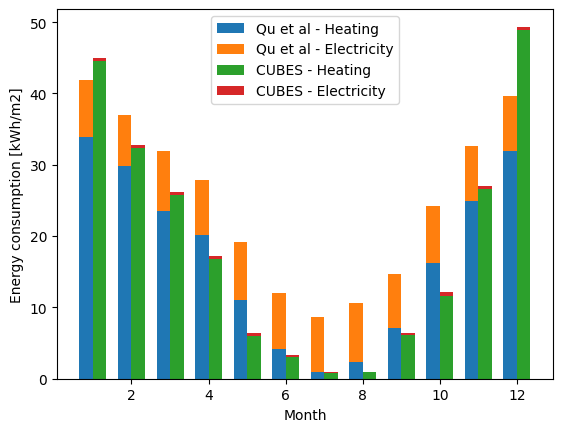

In [62]:
width = 0.35
fig,ax = plt.subplots()
ax.bar(time-width/2,qu_data[qucols[2]],width,label='Qu et al - Heating')
ax.bar(time-width/2,qu_data[qucols[1]],width,bottom=qu_data[qucols[2]],label='Qu et al - Electricity')
ax.bar(time+width/2,cubes_data_by_month[ccols[-2]]/1000/floor_area,width,label='CUBES - Heating')
ax.bar(time+width/2,cubes_data_by_month[ccols[-3]]/1000/floor_area,width,bottom=cubes_data_by_month[ccols[-2]]/1000/floor_area,label='CUBES - Electricity')
ax.set_xlabel('Month')
ax.set_ylabel('Energy consumption [kWh/m2]')
ax.legend()

In [63]:
print(singh_energy.iloc[-1]*2.77778e-10,cubes_energy.iloc[-1]*2.77778e-10)

NameError: name 'singh_energy' is not defined